# Tutorial 02 — Frequentist fitting

Two complementary entry points fit a model with SciPy least squares:

1. **`fairfluids.analysis.regression`** — a high-level, document-oriented engine. Give it a model
   *name* and FAIRFluids documents; it groups the data, fits every group, and returns a universal
   `ParameterStack` (plus backward-compatible `fit_arrhenius` / `fit_vft` DataFrame wrappers).
2. **`fairfluids.analysis.fit`** (alias `ff`) — the low-level backend that fits *any*
   `SymbolicModel` you declared yourself, from a prepared `BayesianDataset`.

Both share the **same** compiled kernels from the symbolic store, so they agree.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import numpy as np
import pandas as pd
import sympy as sp

# Absolute data paths so the notebook runs from anywhere.
ROOT = "/home/sga/Code/FAIRFluids"
DENSITY = os.path.join(ROOT, "transition_water", "data", "Density")
VISCOSITY = os.path.join(ROOT, "transition_water", "data", "Viscosity")

import glob
from fairfluids import FAIRFluidsDocument
from fairfluids.analysis import regression as reg
from fairfluids.analysis import models as fm
from fairfluids.analysis import fit as ff

visc_file = os.path.join(VISCOSITY, "Glycerol", "glycerol_water.json")
doc = FAIRFluidsDocument.model_validate_json(open(visc_file).read())
print("regression models:", reg.list_models())

regression models: ['arrhenius', 'density_exp_poly', 'density_exp_poly_degC_anchored', 'density_exp_poly_t0', 'density_exp_poly_t0_anchored', 'density_exp_poly_t0_mean_centered', 'extended_arrhenius', 'litovitz', 'litovitz_extended', 'vft']


## 1. High-level: fit a named model across documents

`reg.fit_documents` returns a `ParameterStack` — a list of per-group `FitResult`s with a tidy
`to_dataframe()` view. Each row carries the fitted parameters, their std-errors, derived quantities
and the group's R².

In [2]:
stack = reg.fit_documents("vft", {"Glycerol + Water": doc},
                          property_type="viscosity", min_points=4)
df = stack.to_dataframe()
print(f"{len(df)} groups fitted with VFT")
df.round(4).head()

8 groups fitted with VFT


,model_name,source_doi,fluid_compounds,mole_fractions,n_points,R_squared,T_min,T_max,B,B_std,T0,T0_std,ln_eta0,ln_eta0_std,eta0,eta0_std
0,vft,10.1016/j.molliq.2023.122120,"(Choline Chloride, Water)","(0.0476, 0.9524)",9,0.9993,278.15,318.15,2204.9255,1433.3559,-31.5541,106.7953,-13.3156,2.1785,0.0000,0.0000
1,vft,10.1016/j.molliq.2023.122120,"(Choline Chloride, Water)","(0.0909, 0.9091)",9,0.9993,278.15,318.15,257.6557,56.4738,185.7210,11.9539,-8.4766,0.2561,0.0002,0.0001
2,vft,10.1016/j.molliq.2023.122120,"(Choline Chloride, Water)","(0.125, 0.875)",9,0.9987,278.15,318.15,910.9887,458.0723,103.4980,48.4531,-10.3938,1.1842,0.0000,0.0000
3,vft,10.1016/j.molliq.2023.122120,"(Choline Chloride, Water)","(0.1429, 0.8571)",9,1.0000,278.15,318.15,737.4894,63.3402,124.0935,7.3818,-9.7851,0.1834,0.0001,0.0000
4,vft,10.1016/j.molliq.2023.122120,"(Choline Chloride, Water)","(0.1667, 0.8333)",9,0.9998,278.15,318.15,666.9331,106.5496,137.6566,12.6331,-9.3852,0.3351,0.0001,0.0000


### Backward-compatible DataFrame wrappers

`fit_arrhenius`, `fit_extended_arrhenius` and `fit_vft` keep the old call signature (a DataFrame in,
a DataFrame out) for existing analysis scripts. They read straight from an extracted property frame.

In [3]:
from fairfluids.analysis import extract_property_dataframe

vdf = extract_property_dataframe(doc, property_type="viscosity",
                                 keep_only_relevant_columns=False)
arr_df = reg.fit_arrhenius(vdf, viscosity_col="viscosity_value", min_points=4)
print("Arrhenius columns:", [c for c in arr_df.columns if c in
      ("Ea_J_mol", "Ea_kJ_mol", "lnA", "R_squared")])
arr_df[[c for c in ("source_doi", "Ea_kJ_mol", "lnA", "R_squared") if c in arr_df.columns]].round(3).head()

Arrhenius columns: ['Ea_J_mol', 'Ea_kJ_mol', 'R_squared']


,source_doi,Ea_kJ_mol,R_squared
0,10.1016/j.molliq.2023.122120,14.980,0.999
1,10.1016/j.molliq.2023.122120,15.413,0.995
2,10.1016/j.molliq.2023.122120,17.865,0.998
3,10.1016/j.molliq.2023.122120,18.128,0.999
4,10.1016/j.molliq.2023.122120,19.319,0.999


## 2. Low-level: fit a model you declared yourself

Declare a custom Arrhenius model and fit it through the shared backend. We use a `BayesianDataset`
purely as a **fit-ready data container** (no Bayesian inference involved here).

In [4]:
from fairfluids.analysis.bayesian import BayesianDataset

T, Ea, logA = sp.symbols("T Ea logA")
R = 8.314
arr = fm.define_model(
    "tut02_arrhenius", property="viscosity",
    expr=sp.exp(logA + Ea / (R * T)), features=["T"],
    p0={"logA": -10.0, "Ea": 15000.0},
    derived={"Ea_kJ_mol": "Ea / 1000"}, derived_units={"Ea_kJ_mol": "kJ/mol"},
    overwrite=True,
)

ds = BayesianDataset.from_documents(
    {"Glycerol + Water": doc}, property="viscosity", features=["temperature"],
    group_by=["source_doi", "mole_fraction_water"], min_points=4, log_observation=True,
)
print("groups:", len(ds))

group = max(ds.groups, key=lambda g: g.n_points)
fit = ff.fit_group(arr, group, feature_map={"T": "temperature"})
print("success :", fit.success, " r2 =", round(fit.r_squared, 5))
print("params  :", {k: (round(v, 4), None if s is None else round(s, 4))
                    for k, (v, s) in fit.params.items()})
print("derived :", {k: (round(v, 2), None if s is None else round(s, 2))
                    for k, (v, s) in fit.derived.items()})

groups: 8
success : True  r2 = 0.99938
params  : {'Ea': (27795.8139, 262.0527), 'logA': (-14.7073, 0.106)}
derived : {'Ea_kJ_mol': (27.8, 0.26)}


/home/sga/Code/FAIRFluids/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_18986/840455904.py:13: UserWarning: Measurement uncertainty missing for 8/8 groups (100 %). Those groups will rely solely on model_sigma. Check whether 'viscosity'_uncertainty is present in the source documents if you expected per-point sigmas.
  ds = BayesianDataset.from_documents(


### Derived-quantity error propagation

The `Ea_kJ_mol` value above already carries a **propagated** standard error (delta method on the
parameter covariance). You declare the reparametrisation once; the backend does the calculus.

In [5]:
ea_val, ea_std = fit.derived["Ea_kJ_mol"]
print(f"Activation energy: {ea_val:.2f} +/- {ea_std:.2f} kJ/mol")

Activation energy: 27.80 +/- 0.26 kJ/mol


## 3. Fit the whole dataset at once

`ff.fit_dataset` fits every group, collecting failures instead of crashing, and `to_frame()`
tabulates the result.

In [6]:
res = ff.fit_dataset(arr, ds, feature_map={"T": "temperature"})
print(f"fitted {len(res)} groups, {res.n_failed} failed")
res.to_frame().round(4).head()

fitted 8 groups, 0 failed


,group_label,Ea,Ea_std,logA,logA_std,Ea_kJ_mol,Ea_kJ_mol_std,r_squared
0,10.1016/j.molliq.2023.122120 | 0.6667,27795.8139,262.0527,-14.7073,0.1060,27.7958,0.2621,0.9994
1,10.1016/j.molliq.2023.122120 | 0.75,24389.5566,334.9061,-14.1851,0.1355,24.3896,0.3349,0.9987
2,10.1016/j.molliq.2023.122120 | 0.8,20487.5482,290.4071,-13.1869,0.1175,20.4875,0.2904,0.9986
3,10.1016/j.molliq.2023.122120 | 0.8333,19317.7691,262.0389,-13.0103,0.1060,19.3178,0.2620,0.9987
4,10.1016/j.molliq.2023.122120 | 0.8571,18126.6236,194.2725,-12.8508,0.0786,18.1266,0.1943,0.9992


## 4. Plot a fit

Compile the kernel and overlay the least-squares curve on the data. Remember the model is fitted on
`ln(viscosity)`, so we exponentiate for a linear-scale plot.

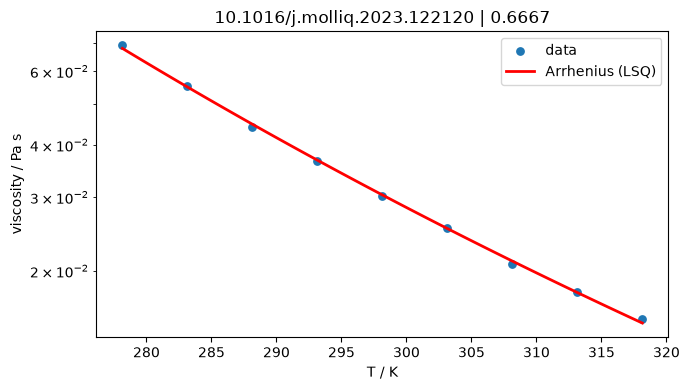

In [7]:
import matplotlib.pyplot as plt

kernel = fm.compile_numpy(arr)        # arg order: T, Ea, logA
Tg = np.asarray(group.features["temperature"], float)
eta = np.asarray(group.raw_observation, float)
Tline = np.linspace(Tg.min(), Tg.max(), 100)
eta_line = np.exp(kernel(Tline, fit.values()["Ea"], fit.values()["logA"]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(Tg, eta, s=28, label="data")
ax.plot(Tline, eta_line, "r-", lw=2, label="Arrhenius (LSQ)")
ax.set_yscale("log")
ax.set_xlabel("T / K"); ax.set_ylabel("viscosity / Pa s")
ax.set_title(str(group.group_label)[:60]); ax.legend(); fig.tight_layout()
plt.show()

## Recap

* `reg.fit_documents(name, docs)` → `ParameterStack.to_dataframe()` is the quick, document-driven path.
* `reg.fit_arrhenius / fit_vft / fit_extended_arrhenius` keep the legacy DataFrame interface.
* `ff.fit_group` / `ff.fit_dataset` fit **your own** declared models through the same kernels.
* Declared **derived quantities** come back with propagated uncertainties — no manual error algebra.

**Next:** `03_bayesian_inference.ipynb` — the same models, full posterior.